<div class='alert alert-block alert-warning'>
    <h3><b>AI Usage in the project</b></h3>
    <hr style="border-top: 1px dashed #943e13; margin-top: 5px; margin-bottom: 10px;">
    <ul>
        <li><b>Consultation:</b> We used the new extended Gemini flash model to consulte about possible optimizations to ensure our model runs faster and smoother. </li>
        <li><b>Code optimization:</b> Asked the LLM to produce minimal changes to code to optimize it after consultation and our personal understanding of the code.</li>
        <li><b>Machine Learning knowledge:</b> Additionally used the LLM to help us better understand learned principals in machine learning.</li>
    </ul>
    <hr style="border-top: 1px dashed ##943e13; margin-top: 5px; margin-bottom: 10px;">
    <ul>
        <h5><b>Prompt examples:</b></h5>
        <li>Explain to me PCA's cumulative variance</li>
        <li>I am making a machine learning project that uses a mnist handwritten numbers dataset (0-9). It is a dataframe of a colomuns of labels and the rest are the pixels with their values from 0 to 255 representing the flattened images corresponding to the labels. How can I vizualize the numbers?</li>
</div>

In [166]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tqdm import tqdm

!pip install tqdm

<div class="alert alert-block alert-info">
    <h3>Step 1: Load & Inspect Datasets</h3>
    <hr style="border-top: 1px dashed #bce8f1; margin-top: 5px; margin-bottom: 10px;">
    <ul>
        <li><b>Load Train Set:</b> Read the training data and display its structure.</li>
        <li><b>Load Test Set:</b> Read the test data and display it to verify consistency.</li>
    </ul>
</div>

In [167]:
def load_csv(file_path):
    return pd.read_csv(file_path)

In [168]:
df_train = load_csv("mnist-handwritten-dataset/train.csv")
df_train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [169]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


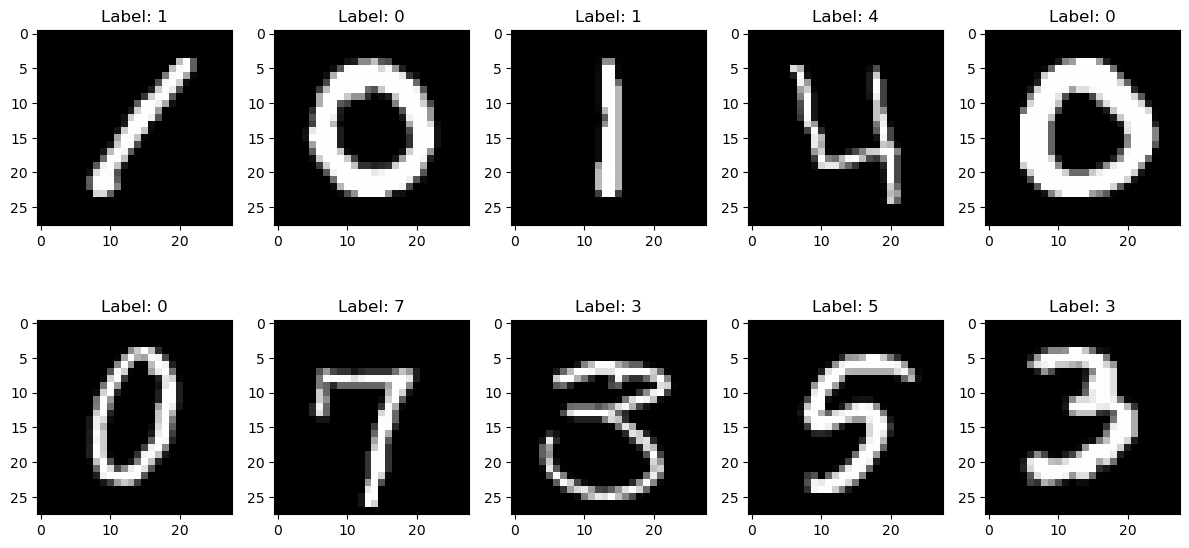

In [170]:
plt.figure(figsize=(12, 6))

for i in range(10):
    row = df_train.iloc[i]
    
    # 1. Separate label and reshape the 784 pixels to a 28x28 grid
    label = row['label']
    pixels = row.drop('label').values.reshape(28, 28)
    
    # 2. Position the subplot (2 rows, 5 columns, index starts at 1)
    plt.subplot(2, 5, i + 1)
    
    # 3. Render the image
    plt.imshow(pixels, cmap='gray')
    plt.title(f"Label: {label}")

# Clean up spacing and display
plt.tight_layout()
plt.show()

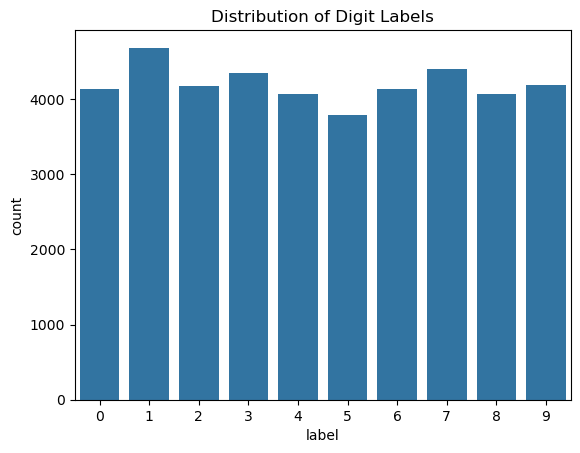

In [171]:
sns.countplot(x='label', data=df_train)
plt.title("Distribution of Digit Labels")
plt.show()

In [172]:
df_train['label'].value_counts().sort_index()

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

In [173]:
df_test = load_csv("mnist-handwritten-dataset/test.csv")
df_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [174]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Columns: 784 entries, pixel0 to pixel783
dtypes: int64(784)
memory usage: 167.5 MB


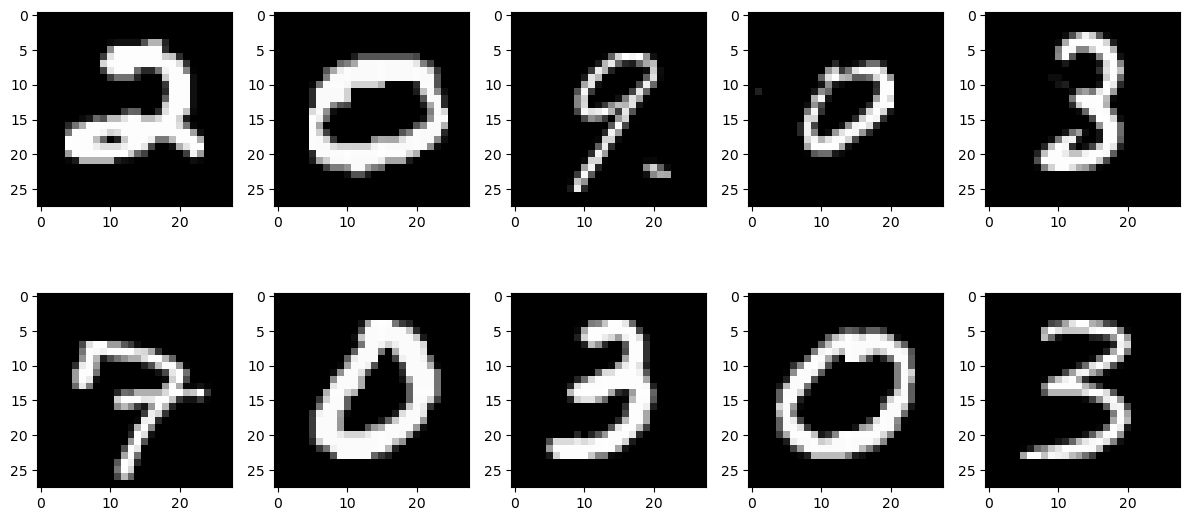

In [175]:
plt.figure(figsize=(12, 6))

for i in range(10):
    row = df_test.iloc[i]
    
    pixels = row.values.reshape(28, 28)
    
    plt.subplot(2, 5, i + 1)
    
    plt.imshow(pixels, cmap='gray')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
    <h3>Step 2: Initial testing</h3>
    <hr style="border-top: 1px dashed #bce8f1; margin-top: 5px; margin-bottom: 10px;">
    <ul>
        <li>Before stepping into optimization of the hyperparameters, let's look at how the baseline performs.</li>
        <li><b>Metrics:</b> We will look at the differences between different distance metrics.</li>
        <li><b>Split:</b> We will first separate the labels from the vectors then split the train set to validate as the test set lacks labels.</li>
    </ul>
</div>

In [176]:
class CustomKNN:
    def __init__(self, k=3, metric="euclidean"):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _distance(self, x):
        diff = self.X_train - x

        if self.metric == "euclidean":
            return np.linalg.norm(diff, axis=1)

        elif self.metric == "manhattan":
            return np.sum(np.abs(diff), axis=1)

        elif self.metric == "chebyshev":
            return np.max(np.abs(diff), axis=1)

    def predict_one(self, x):
        #Predicting for a single point of data
        distances = self._distance(x)

        k_indices = np.argpartition(distances, self.k)[:self.k]
        k_labels = self.y_train[k_indices]

        values, counts = np.unique(k_labels, return_counts=True)
        return values[counts.argmax()]

    def predict(self, X):
        #Prediction loop for the whole set
        return np.array([self.predict_one(x) for x in tqdm(X)])

    def compute_macro_f1(self, y_true, y_pred):
        #Macro F1 score - Calculates individual F1 scores for each digit then takes them and returns the mean
        unique_classes = np.unique(y_true)
        f1_scores = []
    
        for c in unique_classes:
            tp = np.sum((y_true == c) & (y_pred == c))
            fp = np.sum((y_true != c) & (y_pred == c))
            fn = np.sum((y_true == c) & (y_pred != c))
        
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        
            if (precision + recall) > 0:
                f1 = 2 * (precision * recall) / (precision + recall)
            else:
                f1 = 0.0
            f1_scores.append(f1)
        
        return np.mean(f1_scores)


    def compute_confusion_matrix(self, y_true, y_pred, num_classes=10):
        #Uses prediction data and labels to display heatmap style confusion matrix
        cm = np.zeros((num_classes, num_classes), dtype=int)
        for true, pred in zip(y_true, y_pred):
            cm[true, pred] += 1
        plt.figure(figsize=(7, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
                    xticklabels=range(num_classes), yticklabels=range(num_classes),
                    cbar_kws={'label': 'Number of Images'})
        
        plt.title(f"Confusion Matrix Evaluation\nModel: K={self.k} | Metric='{self.metric}'", 
                  fontsize=13, fontweight='bold', pad=20)
        plt.xlabel("Predicted Digit Label", fontsize=11, labelpad=10)
        plt.ylabel("True Authentic Label", fontsize=11, labelpad=10)
        
        plt.tight_layout()
        plt.show()
        

In [177]:
X_train = df_train.iloc[:, 1:].values   # all pixel columns
y_train = df_train.iloc[:, 0].values    # label column

In [178]:
X_test = df_test.values

100%|██████████| 300/300 [00:02<00:00, 119.21it/s]



     BASELINE KNN RUN SUMMARY     
Neighborhood Size K:  3
Distance Metric:      EUCLIDEAN
Validation Macro F1:  88.40%


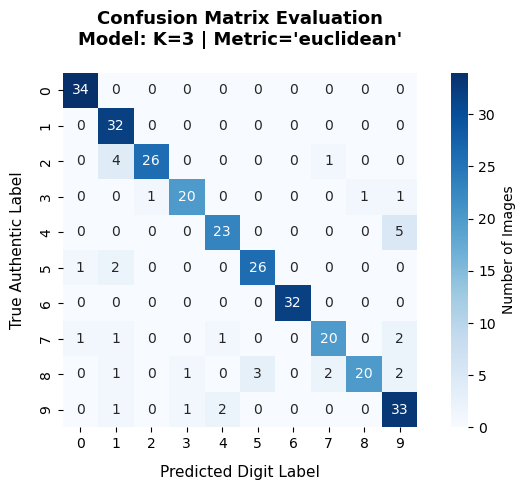

Distance Metric:      MANHATTAN
Validation Macro F1:  87.18%


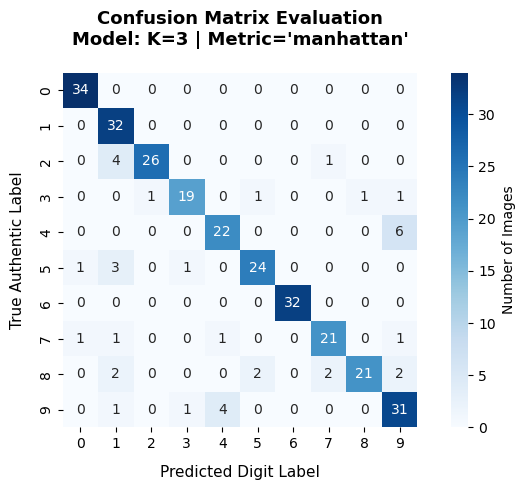

Distance Metric:      CHEBYSHEV
Validation Macro F1:  50.03%


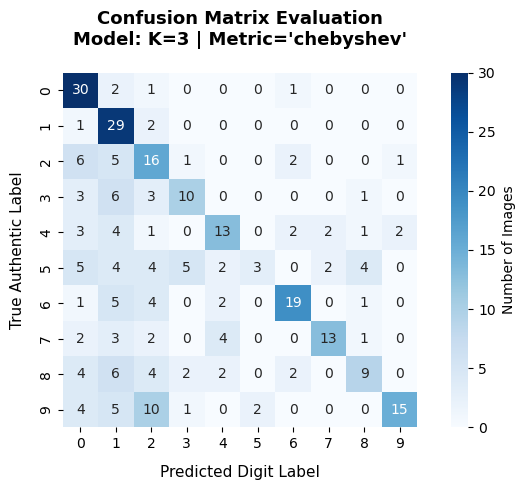

In [179]:
# (1500 samples to build the neighborhood, 300 samples to validate against)
X_train_sample = X_train[:1500]
y_train_sample = y_train[:1500]

X_val = X_train[1500:1800]
y_val = y_train[1500:1800]

# =====================================================================
# MODEL INFERENCE & EVALUATION
# =====================================================================
knn_euc = CustomKNN(k=3, metric='euclidean')
knn_euc.fit(X_train_sample, y_train_sample)
predictions_euc = knn_euc.predict(X_val)
macro_f1_score_euc = knn_euc.compute_macro_f1(y_val, predictions_euc)

knn_manh = CustomKNN(k=3, metric='manhattan')
knn_manh.fit(X_train_sample, y_train_sample)
predictions_manh = knn_manh.predict(X_val)
macro_f1_score_manh = knn_manh.compute_macro_f1(y_val, predictions_manh)

knn_cheby = CustomKNN(k=3, metric='chebyshev')
knn_cheby.fit(X_train_sample, y_train_sample)
predictions_cheby = knn_cheby.predict(X_val)
macro_f1_score_cheby = knn_cheby.compute_macro_f1(y_val, predictions_cheby)

# =====================================================================
# DISPLAY RESULTS
# =====================================================================
print("\n" + "="*45)
print("     BASELINE KNN RUN SUMMARY     ")
print("="*45)
print(f"Neighborhood Size K:  3")
print("="*45)
print(f"Distance Metric:      {knn_euc.metric.upper()}")
print(f"Validation Macro F1:  {macro_f1_score_euc * 100:.2f}%")
knn_euc.compute_confusion_matrix(y_val, predictions_euc)
print("="*45)
print(f"Distance Metric:      {knn_manh.metric.upper()}")
print(f"Validation Macro F1:  {macro_f1_score_manh * 100:.2f}%")
knn_manh.compute_confusion_matrix(y_val, predictions_manh)
print("="*45)
print(f"Distance Metric:      {knn_cheby.metric.upper()}")
print(f"Validation Macro F1:  {macro_f1_score_cheby * 100:.2f}%")
knn_cheby.compute_confusion_matrix(y_val, predictions_cheby)
print("="*45)

<div class="alert alert-block alert-info">
    <h3>Step 3: Feature Engineering</h3>
    <hr style="border-top: 1px dashed #bce8f1; margin-top: 5px; margin-bottom: 10px;">
    <ul>
        <li><b>Normalization:</b> Perform Mix-Max normalization by dividing all the vectors by 255.0 (max saturation value).</li>
        <li><b>Best hyperparameters:</b> Calculate best n_components for PCA through cumulative variance elbow method and best k_neighbors through K-fold cross validation.</li>
        <li><b>Transform vectors</b>: Use the calculated n_components to transform the X matrixes.</li>
    </ul>
</div>

In [180]:
X_train = X_train / 255.0
X_test = X_test / 255.0

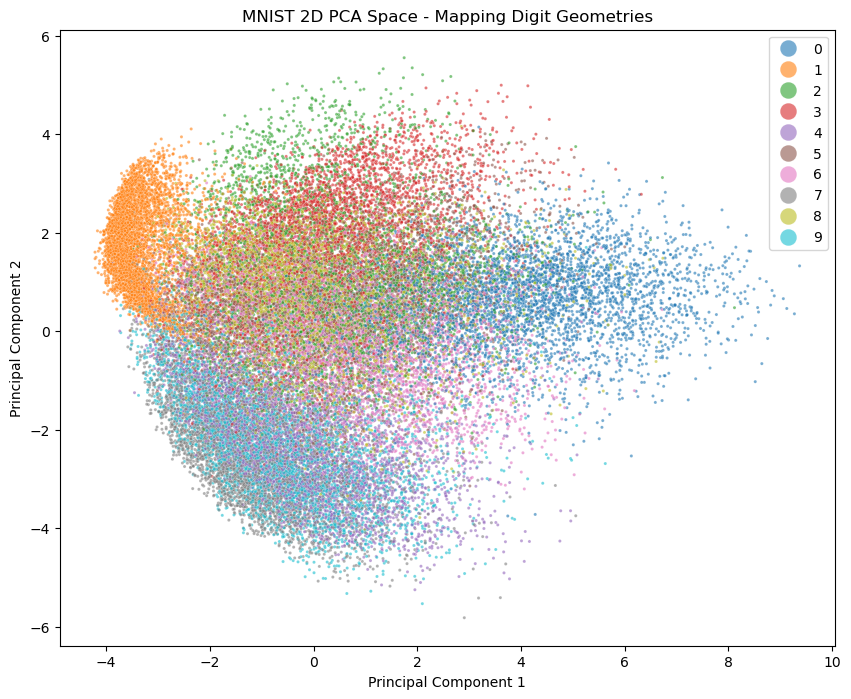

In [188]:
#Project down to exactly 2 dimensions for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

#Plot the landscape
plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], 
    hue=y, palette='tab10', legend='full', alpha=0.6, s=5
)
# This grabs the existing legend and changes the marker size to 50
leg = ax.get_legend()
for handle in leg.legend_handles:
    handle.set_markersize(12)
plt.title("MNIST 2D PCA Space - Mapping Digit Geometries")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

To preserve 95% of the information, you need exactly: 154 components.


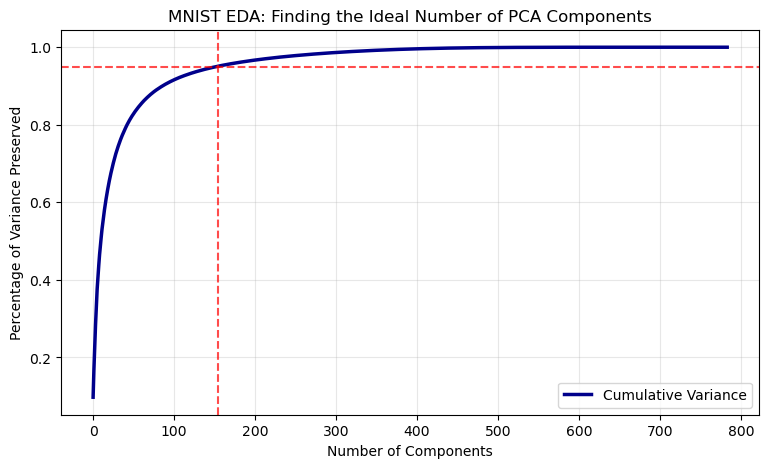

In [182]:
# 2. Fit PCA with all possible components (784)
pca_full = PCA()
pca_full.fit(X_train)

# 3. Calculate the cumulative sum of the variance ratios
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 4. Find the exact number of components needed for 95% variance
# We add 1 because index arrays start at 0
ideal_components = np.argmax(cumulative_variance >= 0.95) + 1

print(f"To preserve 95% of the information, you need exactly: {ideal_components} components.")

# 5. Plot the Scree / Cumulative Variance curve
plt.figure(figsize=(9, 5))
plt.plot(cumulative_variance, lw=2.5, color='darkblue', label='Cumulative Variance')

# Draw lines showing your target threshold
plt.axhline(y=0.95, color='red', linestyle='--', alpha=0.7)
plt.axvline(x=ideal_components, color='red', linestyle='--', alpha=0.7)

plt.title("MNIST EDA: Finding the Ideal Number of PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Percentage of Variance Preserved")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [183]:
def get_stratified_folds_indices(y, n_splits=5, seed=42):
    """
    Manually creates train/validation index splits where each fold 
    maintains the exact same proportion of class labels.
    """
    np.random.seed(seed)
    unique_classes = np.unique(y)
    
    # Step A: Chop indices of each class into n_splits separate chunks
    class_chunks = {}
    for c in unique_classes:
        # Locate row indices belonging to this specific digit class
        indices = np.where(y == c)[0]
        np.random.shuffle(indices)
        
        # np.array_split safely handles arrays that don't divide perfectly equally
        class_chunks[c] = np.array_split(indices, n_splits)
    
    # Step B: Assemble the chunks into complete train/val folds
    folds = []
    for fold_idx in range(n_splits):
        # Validation fold: collect the fold_idx chunk from every class
        val_idx = np.concatenate([class_chunks[c][fold_idx] for c in unique_classes])
        
        # Training fold: collect all other chunks that aren't the current validation chunk
        train_chunks_list = []
        for c in unique_classes:
            for i in range(n_splits):
                if i != fold_idx:
                    train_chunks_list.append(class_chunks[c][i])
        train_idx = np.concatenate(train_chunks_list)
        
        folds.append((train_idx, val_idx))
        
    return folds

Starting Hyperparameter Tuning...

Testing Configuration -> k=1 | metric='euclidean'


100%|██████████| 297/297 [00:01<00:00, 167.35it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 87.30%


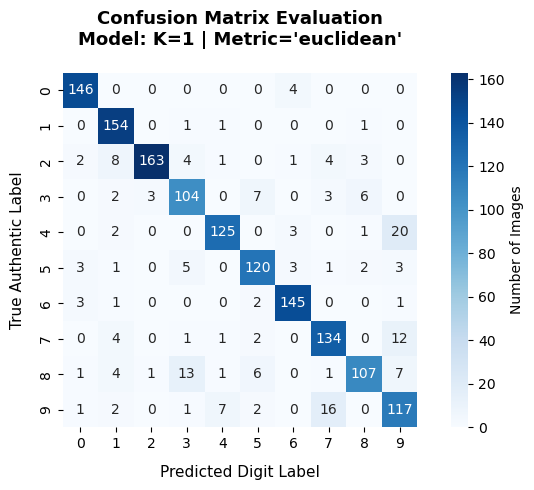


Testing Configuration -> k=3 | metric='euclidean'


100%|██████████| 297/297 [00:01<00:00, 162.15it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 86.97%


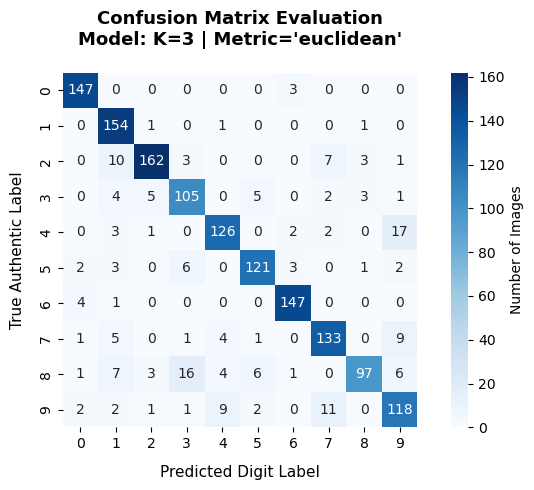


Testing Configuration -> k=5 | metric='euclidean'


100%|██████████| 297/297 [00:01<00:00, 162.04it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 86.83%


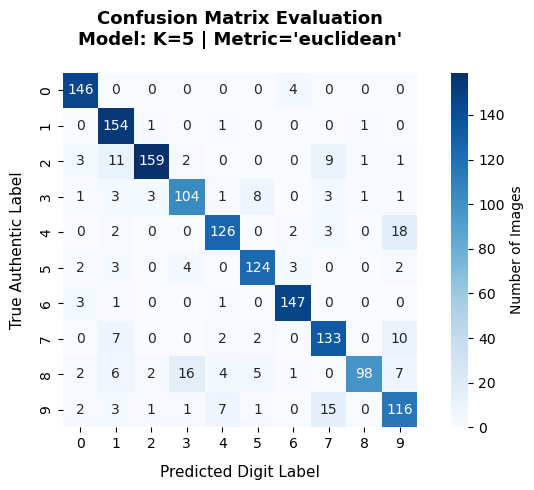


Testing Configuration -> k=7 | metric='euclidean'


100%|██████████| 297/297 [00:01<00:00, 170.16it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 86.27%


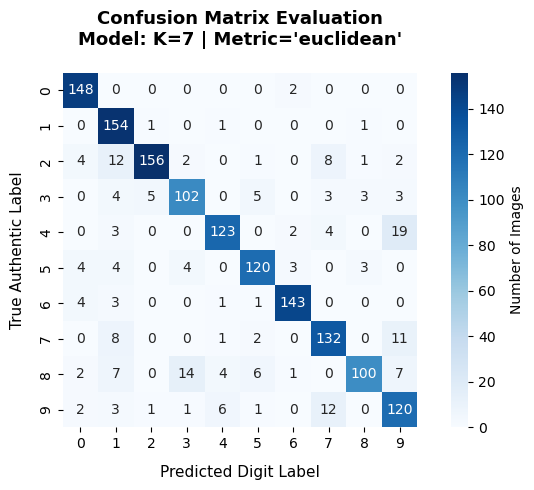


Testing Configuration -> k=9 | metric='euclidean'


100%|██████████| 297/297 [00:01<00:00, 163.98it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 86.51%


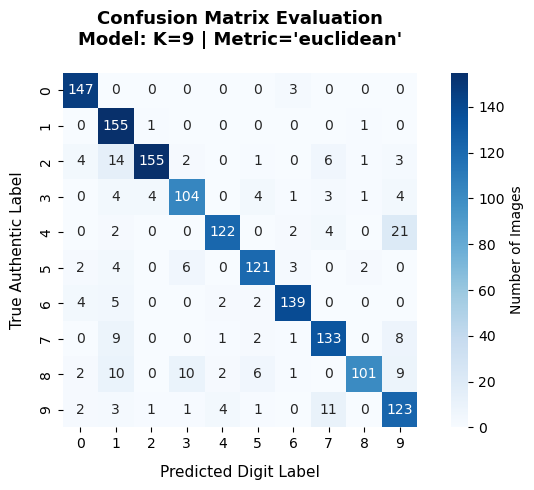


Testing Configuration -> k=11 | metric='euclidean'


100%|██████████| 297/297 [00:01<00:00, 161.67it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 85.95%


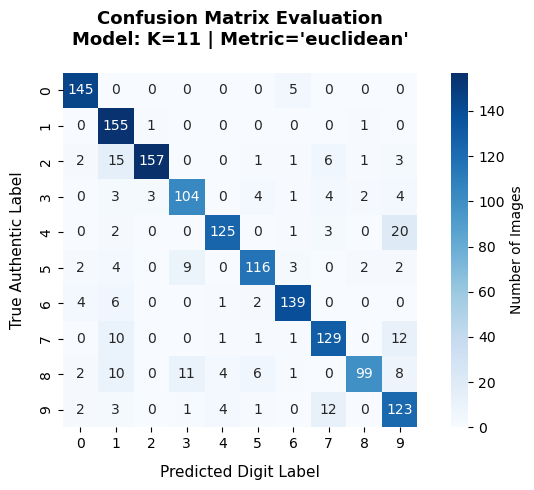


Testing Configuration -> k=13 | metric='euclidean'


100%|██████████| 297/297 [00:01<00:00, 167.47it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 85.81%


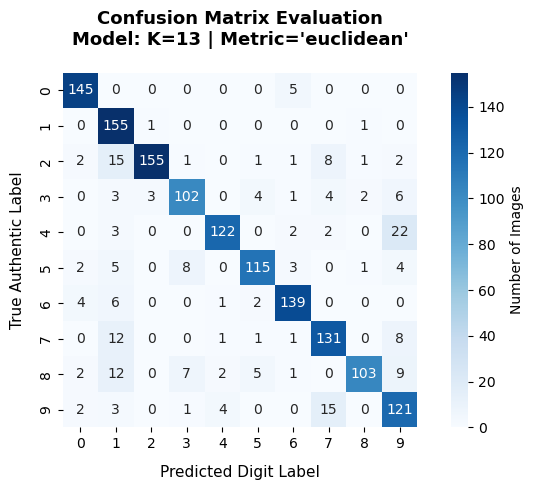


Testing Configuration -> k=15 | metric='euclidean'


100%|██████████| 297/297 [00:01<00:00, 167.18it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 84.92%


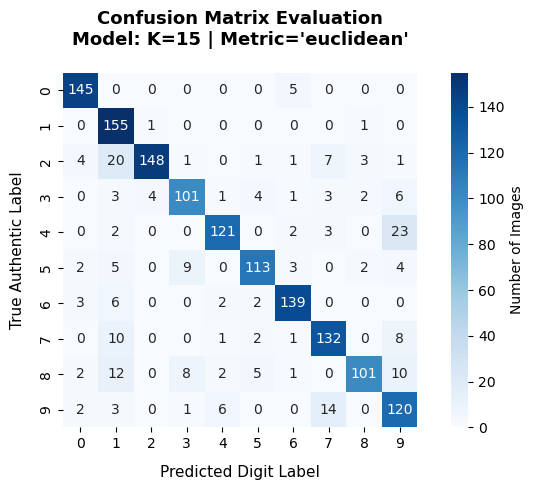


Testing Configuration -> k=1 | metric='manhattan'


100%|██████████| 297/297 [00:01<00:00, 163.19it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 85.82%


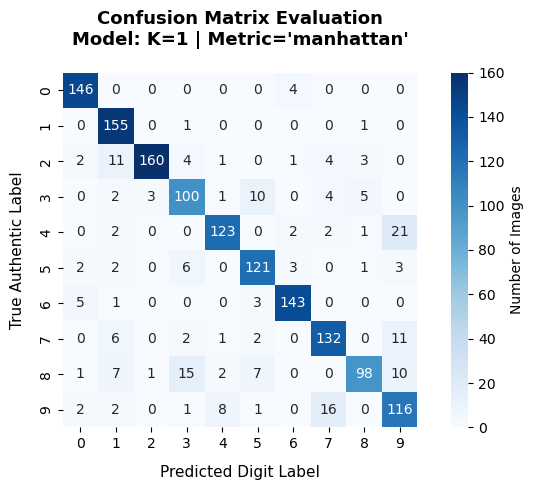


Testing Configuration -> k=3 | metric='manhattan'


100%|██████████| 297/297 [00:01<00:00, 156.13it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 85.67%


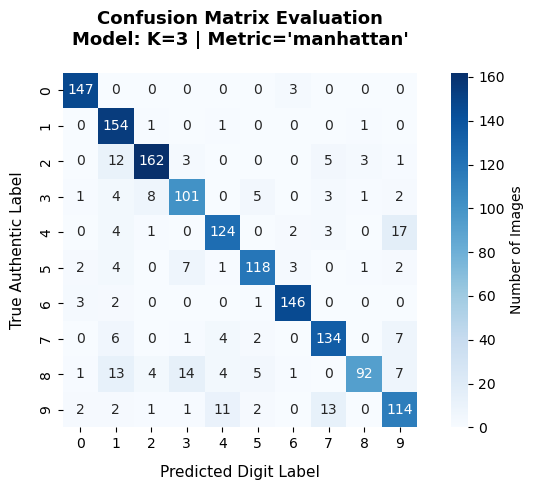


Testing Configuration -> k=5 | metric='manhattan'


100%|██████████| 297/297 [00:01<00:00, 156.95it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 85.49%


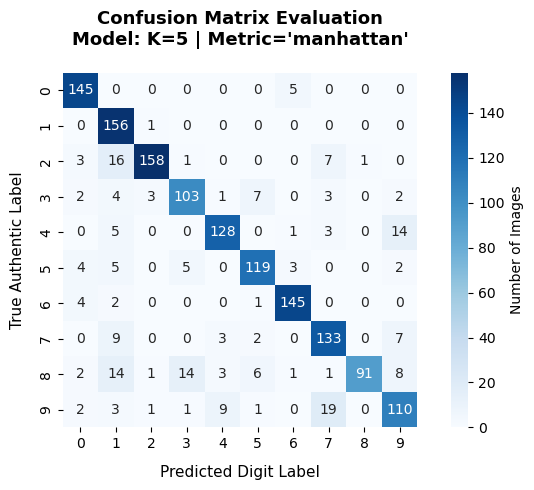


Testing Configuration -> k=7 | metric='manhattan'


100%|██████████| 297/297 [00:01<00:00, 159.09it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 84.81%


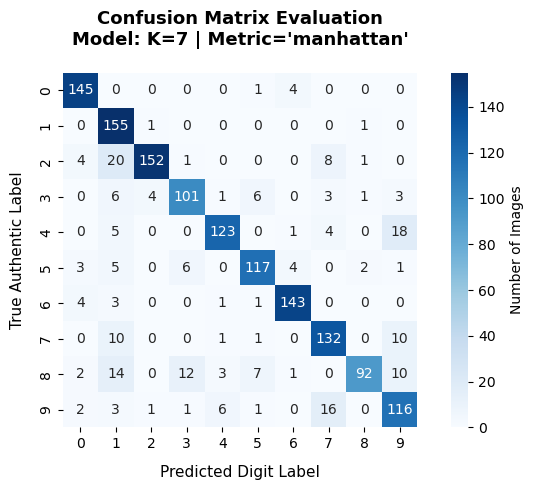


Testing Configuration -> k=9 | metric='manhattan'


100%|██████████| 297/297 [00:01<00:00, 161.92it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 84.64%


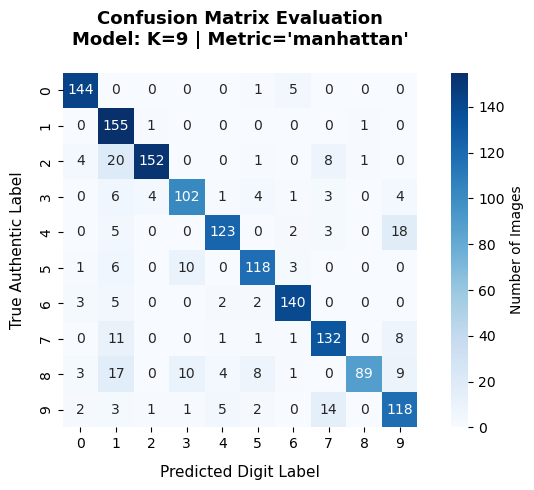


Testing Configuration -> k=11 | metric='manhattan'


100%|██████████| 297/297 [00:01<00:00, 159.65it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 84.22%


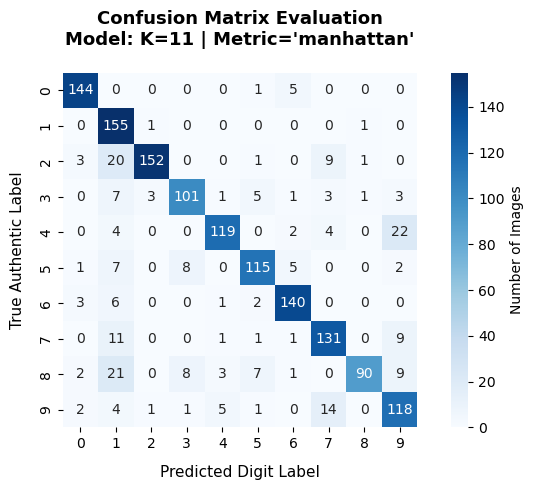


Testing Configuration -> k=13 | metric='manhattan'


100%|██████████| 297/297 [00:01<00:00, 161.51it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 83.59%


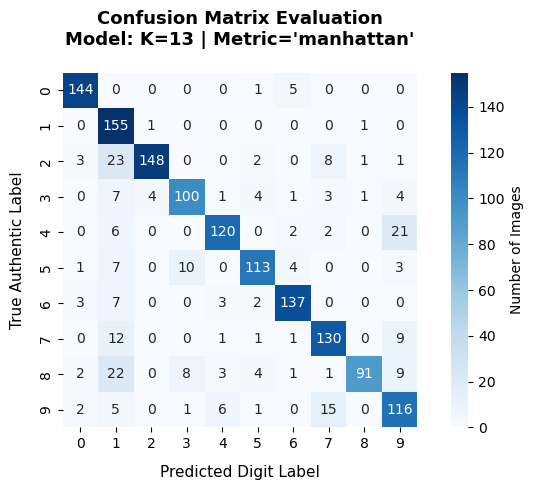


Testing Configuration -> k=15 | metric='manhattan'


100%|██████████| 297/297 [00:01<00:00, 151.23it/s]


-> 5-Fold Cross-Validation Macro F1 Score: 82.73%


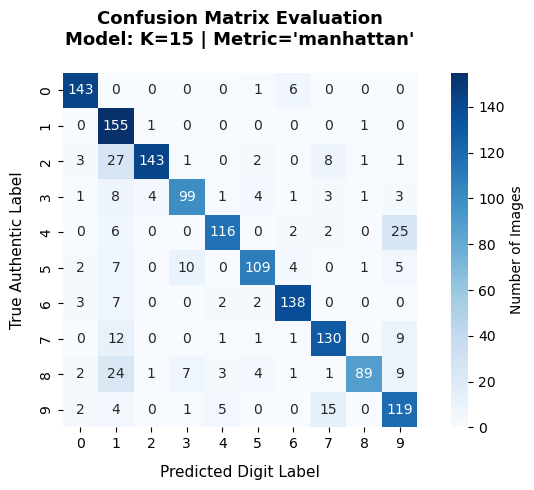

In [191]:
# DOWNSAMPLE ONLY FOR THE GRID SEARCH
X_search = X_train[:1500]
y_search = y_train[:1500]

# Generate our manual stratified folds array
manual_folds = get_stratified_folds_indices(y_search, n_splits=5)

# =====================================================================
# RUN THE CROSS-VALIDATION LOOP
# =====================================================================
# Define hyperparameter testing lists
k_choices = [1, 3, 5, 7, 9, 11, 13, 15]
metrics = ['euclidean', 'manhattan']

best_macro_f1 = -1
best_hyperparameters = {}
grid_rankings = []

print(f"Starting Hyperparameter Tuning...")

for metric in metrics:
    for k in k_choices:
        fold_scores = []
        all_true = []
        all_preds = []
        print(f"\nTesting Configuration -> k={k} | metric='{metric}'")
        
        # Loop through our 5 manually compiled folds
        for fold_num, (train_idx, val_idx) in enumerate(manual_folds, start=1):
            X_train_fold, X_val_fold = X_search[train_idx], X_search[val_idx]
            y_train_fold, y_val_fold = y_search[train_idx], y_search[val_idx]
            
            knn = CustomKNN(k=k, metric=metric)
            knn.fit(X_train_fold, y_train_fold)
            
            predictions = knn.predict(X_val_fold)
            
            fold_f1 = knn.compute_macro_f1(y_val_fold, predictions)
            fold_scores.append(fold_f1)

            all_true.append(y_val_fold)
            all_preds.append(predictions)
            
        # Compute the arithmetic mean performance across all 5 folds
        mean_macro_f1 = np.mean(fold_scores)
        print(f"-> 5-Fold Cross-Validation Macro F1 Score: {mean_macro_f1 * 100:.2f}%")

        knn.compute_confusion_matrix(np.concatenate(all_true), np.concatenate(all_preds))
        
        # Save results for final ranking table
        grid_rankings.append({
            'k': k,
            'metric': metric,
            'macro_f1': mean_macro_f1
        })

In [185]:
# =====================================================================
# PERFORMANCE RANKINGS
# =====================================================================
rankings_df = pd.DataFrame(grid_rankings).sort_values(by='macro_f1', ascending=False)
rankings_df

,k,metric,macro_f1
0,1,euclidean,0.873010
1,3,euclidean,0.869688
2,5,euclidean,0.868330
4,9,euclidean,0.865118
3,7,euclidean,0.862679
5,11,euclidean,0.859523
8,1,manhattan,0.858246
6,13,euclidean,0.858120
9,3,manhattan,0.856715
10,5,manhattan,0.854870


<div class="alert alert-block alert-info">
    <h3>Step 4: Model training</h3>
    <hr style="border-top: 1px dashed #bce8f1; margin-top: 5px; margin-bottom: 10px;">
    <ul>
        <li><b>PCA:</b> Reduce dimensions of X matrixes through optimal n_components PCA.</li>
        <li><b>Build model:</b> Construct the custom KNN model with the optimal hyperparameters from the feature engineering phase.</li>
        <li><b>Fit:</b> Fit KNN model on train set X and y.</li>
    </ul>
</div>

In [105]:
pca = PCA(n_components=154)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [107]:
myKNN = CustomKNN(k=1, metric='euclidean')
myKNN.fit(X_train_pca, y_train)

100%|██████████| 28000/28000 [17:31<00:00, 26.64it/s]


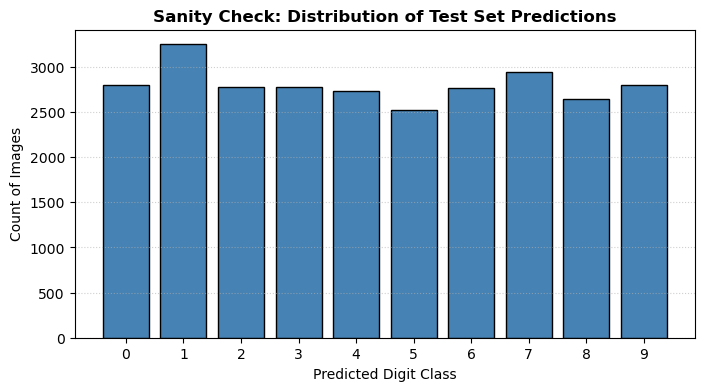

In [108]:
y_test_preds = myKNN.predict(X_test_pca)

# Plot the distribution of predictions
plt.figure(figsize=(8, 4))
bins = np.arange(11) - 0.5
plt.hist(y_test_preds, bins=bins, rwidth=0.8, color='steelblue', edgecolor='black')

plt.title("Sanity Check: Distribution of Test Set Predictions", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Digit Class")
plt.ylabel("Count of Images")
plt.xticks(range(10))
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

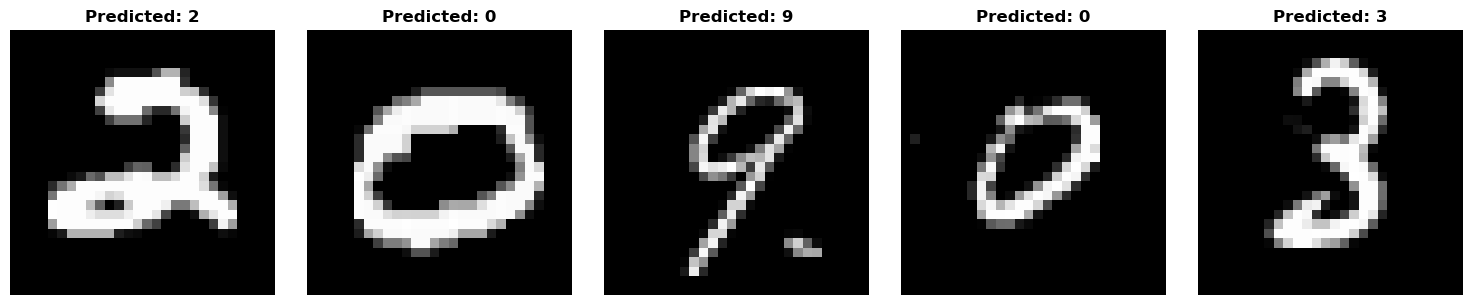

In [189]:
plt.figure(figsize=(15, 3))

for i in range(5):
    # 2. Extract the 784 pixels for the current test sample and reshape to a 28x28 grid
    pixels = X_test[i].reshape(28, 28)
    
    plt.subplot(1, 5, i + 1)
    
    plt.imshow(pixels, cmap='gray')
    
    # 5. Display what your Custom KNN model guessed as the prominent title
    plt.title(f"Predicted: {y_test_preds[i]}", fontsize=12, fontweight='bold')
    
    plt.axis('off')

plt.tight_layout()
plt.show()